If I know nothing about a user, what articles should I recommend?

03_popularity_recommender.ipynb

1. Objective

2. Load processed data

3. Train Popularity Recommender

4. Top 10 Articles

5. Join with article titles

6. Discussion

7. Limitations

8. Next Steps

# Sprint 3 – Popularity-Based Recommendation

## Objective

Build a baseline recommendation model that ranks news articles according to the number of user clicks.

This model serves as the benchmark for evaluating more advanced recommendation algorithms later in the project.

Imports

In [24]:
import pandas as pd
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import MINDDataLoader
from src.data.preprocessing import BehaviorParser
from src.recommenders.popularity import PopularityRecommender

Load Data

In [25]:
loader = MINDDataLoader(
    PROJECT_ROOT / "data" / "raw" / "MINDsmall"
)

news, behaviors = loader.load()

interactions = BehaviorParser.parse_impressions(behaviors)

print(interactions.shape)

(5843444, 3)


Train the Model

In [26]:
model = PopularityRecommender()

model.fit(interactions)

Top 10 Articles

In [27]:
top10 = model.recommend(10)

top10

news_id
N55689    4316
N35729    3346
N33619    3246
N53585    2835
N63970    2578
N49685    2294
N49279    2270
N287      2128
N23446    1930
N51048    1875
Name: clicked, dtype: int64

Make the Results Readable

In [28]:
top10 = model.recommend(10).rename("clicks")

results = news.merge(
    top10,
    left_on="news_id",
    right_index=True,
)

results[
    [
        "title",
        "category",
        "clicks",
    ]
]

,title,category,clicks
32602,Three school workers charged in death of speci...,news,2128
33899,"Charles Rogers, former Michigan State football...",sports,4316
39829,Prince Harry and Meghan Markle just shared a n...,lifestyle,1930
41550,College gymnast dies following training accide...,news,3246
41552,Dean Foods files for bankruptcy,finance,2578
41883,Rep. Tim Ryan endorses Biden in Democratic pri...,news,1875
45974,"Rip Taylor's Cause of Death Revealed, Memorial...",tv,2835
50365,Broadway Actress Laurel Griggs Dies at Age 13,music,2270
50688,Porsche launches into second story of New Jers...,news,3346
50714,Broadway Star Laurel Griggs Suffered Asthma At...,music,2294


Visualization

Top 10 Most Clicked Articles

/var/folders/j0/sggfg3mj4173qr742p48dp780000gn/T/ipykernel_97373/3300691334.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

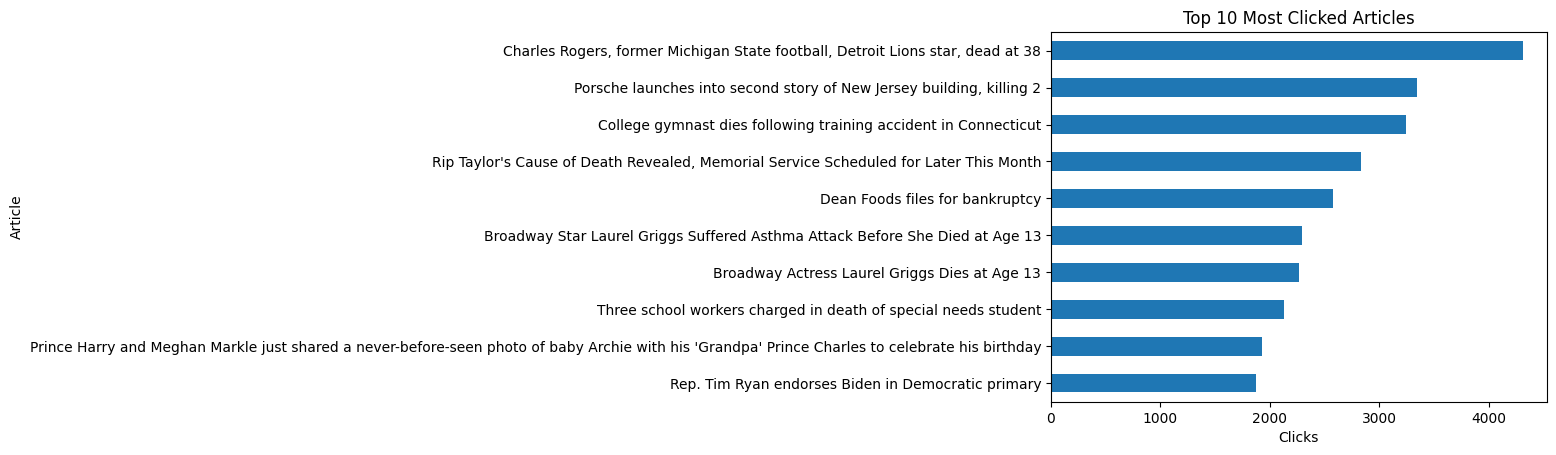

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

results.sort_values("clicks").plot(
    x="title",
    y="clicks",
    kind="barh",
    legend=False
)

plt.title("Top 10 Most Clicked Articles")
plt.xlabel("Clicks")
plt.ylabel("Article")

plt.tight_layout()
plt.show()

## Discussion

## Advantages

- Simple
- Extremely fast
- Strong baseline
- Effective for anonymous users

## Interpretation

The popularity recommender ranks articles by the total number of user clicks.

This approach provides a strong baseline for recommendation systems because it is simple, computationally efficient, and effective for anonymous users.

However, it does not personalize recommendations and tends to favor already-popular content.

## Findings

The popularity-based recommender identifies the articles with the highest number of user clicks across the entire dataset.

### Strengths

- Simple baseline
- Very fast
- Useful for anonymous users
- Easy to interpret

### Limitations

- No personalization
- Popularity bias
- Recommends the same articles to every user
- May reduce content diversity

This model establishes a baseline against which more sophisticated recommendation algorithms can be evaluated.